<a href="https://colab.research.google.com/github/IlaniPrivate/parasha-dakboard/blob/main/diabetes_ml_project_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div dir='rtl'>

# פרויקט הערכה חלופית - מדעי הנתונים ולמידת מכונה

---

**שם התלמיד/ה:** אילן צברי   
**ת"ז:** 027944156  
**שם המחקר:** ניבוי סוכרת על פי מדדי בריאות   
**שנת לימודים:** תשפ"ו   
**שם המורה:** אריאל בן יצחק  

</div>

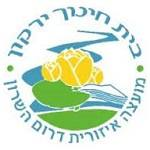

<div dir='rtl'>

# 1. נושא המחקר

## הקדמה

סוכרת היא אחת ממחלות הכרוניות הנפוצות ביותר בעולם, והיא פוגעת במאות מיליוני אנשים. אבחון מוקדם יכול למנוע סיבוכים חמורים ולשפר את איכות החיים.

**מטרת המחקר:** בניית מודל למידת מכונה שיסווג האם אדם סובל מסוכרת (או טרום-סוכרת) על פי מדדי בריאות שונים כגון BMI, לחץ דם, גיל, הרגלי עישון ועוד — נתונים שנאספו בסקר BRFSS 2015 של ה-CDC האמריקאי.

</div>

<div dir='rtl'>

# 2. תיאור הנתונים

## מקור הנתונים

המאגר נלקח מ-Kaggle ונוצר על ידי **Alex Teboul** על בסיס סקר **BRFSS 2015** (Behavioral Risk Factor Surveillance System) של מרכז השליטה במחלות האמריקאי (CDC).  
הסקר נאסף בשנת **2015**, והמאגר עודכן לאחרונה בשנת **2021**.

**קישור למאגר:** https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset

## פרטי המאגר

- **מספר רשומות:** 253,680 (גרסה המלאה) / 70,692 (גרסה מאוזנת 50-50)
- **מספר עמודות:** 22
- **קובץ בשימוש:** `diabetes_binary_health_indicators_BRFSS2015.csv`

## תיאור העמודות

| עמודה | סוג | תיאור |
|---|---|---|
| Diabetes_binary | בינארי (0/1) | **משתנה מטרה** – 0 = אין סוכרת, 1 = יש סוכרת/טרום-סוכרת |
| HighBP | בינארי | לחץ דם גבוה |
| HighChol | בינארי | כולסטרול גבוה |
| CholCheck | בינארי | בדיקת כולסטרול ב-5 שנים האחרונות |
| BMI | רציף | מדד מסת גוף |
| Smoker | בינארי | עישון (100+ סיגריות בחיים) |
| Stroke | בינארי | היסטוריה של שבץ מוחי |
| HeartDiseaseorAttack | בינארי | מחלת לב או התקף לב |
| PhysActivity | בינארי | פעילות גופנית ב-30 ימים האחרונים |
| Fruits | בינארי | צריכת פירות יומית |
| Veggies | בינארי | צריכת ירקות יומית |
| HvyAlcoholConsump | בינארי | שתיית אלכוהול כבדה |
| AnyHealthcare | בינארי | ביטוח/כיסוי רפואי |
| NoDocbcCost | בינארי | נמנע מרופא בגלל עלות |
| GenHlth | קטגוריאלי (1-5) | בריאות כללית (1=מצוין, 5=גרוע) |
| MentHlth | רציף (0-30) | ימים של בריאות נפשית לקויה |
| PhysHlth | רציף (0-30) | ימים של בריאות פיזית לקויה |
| DiffWalk | בינארי | קושי בהליכה/עלייה במדרגות |
| Sex | בינארי | מין (0=נקבה, 1=זכר) |
| Age | קטגוריאלי (1-13) | קבוצת גיל (1=18-24, 13=80+) |
| Education | קטגוריאלי (1-6) | רמת השכלה |
| Income | קטגוריאלי (1-8) | רמת הכנסה |

**משתנה מטרה:** `Diabetes_binary` (סיווג בינארי)  
**תכונות לסיווג:** כל שאר העמודות (21 תכונות)

</div>

# 3. חקר נתונים (EDA)

In [ ]:
# ייבוא ספריות
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

# הגדרת סגנון גרפים
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print('✅ כל הספריות נטענו בהצלחה')

<div dir='rtl'>

## 3.1 טעינת הנתונים

</div>

In [ ]:
# הורדת הנתונים מ-Kaggle
# ⚠️ יש להוריד את הקובץ diabetes_binary_health_indicators_BRFSS2015.csv מ-Kaggle ולהעלות ל-Colab
# או להשתמש בפקודה הבאה אם מותקן kaggle API:
# !kaggle datasets download -d alexteboul/diabetes-health-indicators-dataset --unzip

# טעינת הנתונים
df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')

# הצגת 5 השורות הראשונות
print('גודל המאגר:', df.shape)
df.head()

<div dir='rtl'>

## 3.2 מידע כללי על המאגר (info)

</div>

In [ ]:
# מידע כללי על עמודות, סוגי נתונים וערכים חסרים
df.info()

In [ ]:
# כמות רשומות מכל סיווג (מאוזן/לא מאוזן)
print('התפלגות משתנה המטרה (Diabetes_binary):')
print(df['Diabetes_binary'].value_counts())
print()
print('באחוזים:')
print(df['Diabetes_binary'].value_counts(normalize=True).round(3) * 100)

In [ ]:
# בדיקת ערכים חסרים
missing = df.isnull().sum()
print('ערכים חסרים בכל עמודה:')
print(missing[missing > 0] if missing.sum() > 0 else 'אין ערכים חסרים במאגר ✅')

<div dir='rtl'>

## 3.3 תיאור סטטיסטי של הנתונים (describe)

</div>

In [ ]:
# ממוצע, סטיית תקן, מינימום, חציון, מקסימום
df.describe().round(2)

In [ ]:
# תצפיות מעניינות:
print('ממוצע BMI:', round(df['BMI'].mean(), 2))
print('BMI מינימלי:', df['BMI'].min(), '| BMI מקסימלי:', df['BMI'].max())
print('ממוצע גיל (קטגוריה):', round(df['Age'].mean(), 2))
print('אחוז מעשנים:', round(df['Smoker'].mean()*100, 1), '%')
print('אחוז פעילות גופנית:', round(df['PhysActivity'].mean()*100, 1), '%')

<div dir='rtl'>

## 3.4 ניתוח groupby

</div>

In [ ]:
# groupby #1 - ממוצע BMI לפי סיווג סוכרת
bmi_by_diabetes = df.groupby('Diabetes_binary')['BMI'].mean().round(2)
print('ממוצע BMI לפי סיווג סוכרת:')
print(bmi_by_diabetes)
print()
print('🔍 מסקנה: חולי סוכרת מציגים ממוצע BMI גבוה משמעותית מאנשים ללא סוכרת.')
print('   ממצא זה מחזק את הידוע מהספרות הרפואית על הקשר בין עודף משקל לסוכרת סוג 2.')

In [ ]:
# groupby #2 - שיעור סוכרת לפי קבוצת גיל
diabetes_by_age = df.groupby('Age')['Diabetes_binary'].mean().round(3) * 100
print('שיעור חולי סוכרת (%) לפי קבוצת גיל:')
print(diabetes_by_age)
print()
print('🔍 מסקנה: שיעור הסוכרת עולה בצורה עקבית עם הגיל.')
print('   בקבוצות הגיל הבוגרות (13 = 80+) שיעור הסוכרת גבוה בהרבה.')

In [ ]:
# groupby #3 - השפעת לחץ דם ועישון על שיעור סוכרת
risk_combo = df.groupby(['HighBP', 'Smoker'])['Diabetes_binary'].mean().round(3) * 100
print('שיעור סוכרת (%) לפי שילוב לחץ דם ועישון:')
print(risk_combo)
print()
print('🔍 מסקנה: אנשים עם לחץ דם גבוה ועישון מציגים שיעור סוכרת גבוה ביותר.')
print('   לחץ דם גבוה נראה כגורם סיכון משמעותי יותר מעישון לבדו.')

<div dir='rtl'>

## 3.5 הצגה ויזואלית של הנתונים

</div>

In [ ]:
# גרף 1: התפלגות משתנה המטרה (Countplot - בדיד)
fig, ax = plt.subplots(figsize=(7, 5))
counts = df['Diabetes_binary'].value_counts()
bars = ax.bar(['ללא סוכרת (0)', 'סוכרת/טרום-סוכרת (1)'],
               counts.values,
               color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
ax.set_title('התפלגות משתנה המטרה: סוכרת', fontsize=14, fontweight='bold')
ax.set_ylabel('מספר רשומות')
ax.set_xlabel('סיווג')
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{count:,}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

print('📊 משתנה: Diabetes_binary – בדיד (בינארי)')
print('מסקנה: המאגר מאוזן יחסית – כ-50% חולי סוכרת וכ-50% בריאים.')
print('       לא נדרש איזון נוסף (tags balancing).')

In [ ]:
# גרף 2: התפלגות BMI (Histogram - רציף)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i, (label, color) in enumerate(zip(['ללא סוכרת', 'עם סוכרת'], ['#2ecc71', '#e74c3c'])):
    data = df[df['Diabetes_binary'] == i]['BMI']
    axes[i].hist(data, bins=40, color=color, edgecolor='white', alpha=0.85)
    axes[i].set_title(f'התפלגות BMI – {label}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('BMI')
    axes[i].set_ylabel('תדירות')
    axes[i].axvline(data.mean(), color='black', linestyle='--', label=f'ממוצע: {data.mean():.1f}')
    axes[i].legend()

plt.suptitle('השוואת התפלגות BMI בין חולי סוכרת לבריאים', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('📊 משתנה: BMI – רציף')
print('מסקנה: חולי סוכרת מציגים BMI ממוצע גבוה יותר, עם התפלגות הזזה ימינה.')
print('       ערכי BMI קיצוניים (>60) קיימים בשתי הקבוצות.')

In [ ]:
# גרף 3: שיעור סוכרת לפי גיל (Bar chart - בדיד)
age_labels = {
    1:'18-24', 2:'25-29', 3:'30-34', 4:'35-39', 5:'40-44',
    6:'45-49', 7:'50-54', 8:'55-59', 9:'60-64', 10:'65-69',
    11:'70-74', 12:'75-79', 13:'80+'
}
diabetes_by_age = df.groupby('Age')['Diabetes_binary'].mean() * 100

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar([age_labels[i] for i in diabetes_by_age.index],
              diabetes_by_age.values,
              color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, len(diabetes_by_age))),
              edgecolor='black')
ax.set_title('שיעור חולי סוכרת לפי קבוצת גיל', fontsize=14, fontweight='bold')
ax.set_xlabel('קבוצת גיל')
ax.set_ylabel('שיעור סוכרת (%)')
ax.tick_params(axis='x', rotation=45)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

print('📊 משתנה: Age – בדיד (קטגוריאלי), Diabetes_binary – בדיד (בינארי)')
print('מסקנה: עלייה ברורה בשיעור הסוכרת עם הגיל – מ-~5% בגיל 18-24 לכ-35% ב-80+.')
print('       גיל הוא אחד ממנבאי הסוכרת החזקים ביותר.')

In [ ]:
# גרף 4: Boxplot של BMI לפי מצב סוכרת ומגדר (Boxplot - רציף + בדיד)
fig, ax = plt.subplots(figsize=(9, 6))
df_plot = df.copy()
df_plot['Diabetes'] = df_plot['Diabetes_binary'].map({0: 'ללא סוכרת', 1: 'עם סוכרת'})
df_plot['Sex_label'] = df_plot['Sex'].map({0: 'נקבה', 1: 'זכר'})

sns.boxplot(data=df_plot, x='Diabetes', y='BMI', hue='Sex_label',
            palette=['#e91e8c', '#1e88e5'], ax=ax)
ax.set_title('התפלגות BMI לפי סוכרת ומגדר', fontsize=14, fontweight='bold')
ax.set_xlabel('מצב סוכרת')
ax.set_ylabel('BMI')
ax.legend(title='מגדר')
plt.tight_layout()
plt.show()

print('📊 משתנים: BMI – רציף, Diabetes_binary ו-Sex – בדידים')
print('מסקנה: חציון BMI גבוה יותר בקרב חולי סוכרת בשני המגדרים.')
print('       נשים עם סוכרת מציגות חציון BMI גבוה יותר מגברים עם סוכרת.')

In [ ]:
# גרף 5: גורמי סיכון - Stacked bar (בדיד)
risk_factors = ['HighBP', 'HighChol', 'Smoker', 'Stroke', 'HeartDiseaseorAttack',
                'PhysActivity', 'Fruits', 'Veggies', 'DiffWalk']
labels_heb = ['לחץ דם גבוה', 'כולסטרול גבוה', 'מעשן', 'שבץ', 'מחלת לב',
               'פעיל גופנית', 'אוכל פירות', 'אוכל ירקות', 'קושי בהליכה']

no_diabetes = df[df['Diabetes_binary']==0][risk_factors].mean() * 100
yes_diabetes = df[df['Diabetes_binary']==1][risk_factors].mean() * 100

x = np.arange(len(risk_factors))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, no_diabetes.values, width, label='ללא סוכרת', color='#2ecc71', edgecolor='black')
ax.bar(x + width/2, yes_diabetes.values, width, label='עם סוכרת', color='#e74c3c', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(labels_heb, rotation=35, ha='right')
ax.set_title('השוואת גורמי סיכון: חולי סוכרת מול בריאים', fontsize=14, fontweight='bold')
ax.set_ylabel('אחוז (%)')
ax.legend()
plt.tight_layout()
plt.show()

print('📊 כל המשתנים בדידים (בינאריים)')
print('מסקנה: חולי סוכרת מציגים שיעורים גבוהים יותר של לחץ דם גבוה, כולסטרול גבוה ושבץ.')
print('       מעניין לציין ששיעור פעילות גופנית נמוך יותר בקרב חולי סוכרת.')

In [ ]:
# גרף 6: Violin plot - ימי בריאות גופנית לקויה לפי סוכרת (רציף + בדיד)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i, (col, title) in enumerate(zip(['PhysHlth', 'MentHlth'],
                                      ['ימי בריאות גופנית לקויה', 'ימי בריאות נפשית לקויה'])):
    df_plot2 = df_plot[[col, 'Diabetes']].copy()
    sns.violinplot(data=df_plot2, x='Diabetes', y=col,
                   palette=['#2ecc71', '#e74c3c'], ax=axes[i], inner='box')
    axes[i].set_title(f'התפלגות {title}\nלפי מצב סוכרת', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('מצב סוכרת')
    axes[i].set_ylabel(f'{title} (ימים בחודש)')

plt.suptitle('בריאות גופנית ונפשית לפי מצב סוכרת', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('📊 משתנים: PhysHlth, MentHlth – רציפים; Diabetes_binary – בדיד')
print('מסקנה: חולי סוכרת מדווחים על יותר ימים של בריאות גופנית לקויה.')
print('       ההשפעה על הבריאות הנפשית קיימת אך פחות בולטת.')

<div dir='rtl'>

## 3.6 מפת חום – קורלציה בין מאפיינים למשתנה המטרה

</div>

In [ ]:
# Heatmap של קורלציה
fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = df.corr().round(2)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.5, annot_kws={'size': 7})
ax.set_title('מטריצת קורלציה בין כל המאפיינים', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# קורלציות עם משתנה המטרה
print('\nקורלציות עם Diabetes_binary (מסודר מגבוה לנמוך):')
print(df.corr()['Diabetes_binary'].drop('Diabetes_binary').sort_values(ascending=False).round(3))

# 4. עיבוד נתונים

<div dir='rtl'>

## 4.1 ניקיון – Data Cleaning

</div>

In [ ]:
# שמירת עותק של הנתונים המקוריים
df_clean = df.copy()

# בדיקת ערכים חסרים
print('ערכים חסרים לפני ניקיון:')
print(df_clean.isnull().sum().sum(), 'ערכים חסרים סה"כ')

In [ ]:
# בדיקת שורות כפולות
duplicates = df_clean.duplicated().sum()
print(f'מספר שורות כפולות: {duplicates}')

# הסרת כפילויות
df_clean = df_clean.drop_duplicates()
print(f'גודל המאגר לאחר הסרת כפילויות: {df_clean.shape}')

In [ ]:
# בדיקת ערכי קיצון (outliers) ב-BMI
Q1 = df_clean['BMI'].quantile(0.25)
Q3 = df_clean['BMI'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 3 * IQR
upper = Q3 + 3 * IQR

outliers = df_clean[(df_clean['BMI'] < lower) | (df_clean['BMI'] > upper)]
print(f'ערכי קיצון ב-BMI (גבול: {lower:.1f} - {upper:.1f}): {len(outliers)} רשומות')
print('החלטה: נשמור ערכי קיצון אלה – הם ייתכנו במציאות (BMI גבוה מאוד).')

<div dir='rtl'>

## 4.2 הנדסת מאפיינים – Features Engineering

</div>

In [ ]:
# יצירת מאפיין חדש: BMI_Category (הפיכת רציף לבדיד)
df_clean['BMI_Category'] = pd.cut(df_clean['BMI'],
                                    bins=[0, 18.5, 25, 30, 35, 100],
                                    labels=['תת-משקל', 'תקין', 'עודף משקל', 'השמנה', 'השמנה חמורה'])

# המרה למספרים
bmi_mapping = {'תת-משקל': 0, 'תקין': 1, 'עודף משקל': 2, 'השמנה': 3, 'השמנה חמורה': 4}
df_clean['BMI_Category_num'] = df_clean['BMI_Category'].map(bmi_mapping)

print('קטגוריות BMI שנוצרו:')
print(df_clean['BMI_Category'].value_counts())

In [ ]:
# יצירת מאפיין חדש: RiskScore - ציון סיכון מצטבר
# שילוב גורמי סיכון מוכרים לסוכרת
df_clean['RiskScore'] = (df_clean['HighBP'] + df_clean['HighChol'] +
                          df_clean['Stroke'] + df_clean['HeartDiseaseorAttack'] +
                          df_clean['DiffWalk'])

print('התפלגות ציון הסיכון המצטבר:')
print(df_clean['RiskScore'].value_counts().sort_index())

In [ ]:
# המרת GenHlth מ-1-5 (1=מצוין) לכיוון הפוך כדי שגבוה = בריא יותר
# GenHlth כבר בסדר (1=מצוין, 5=גרוע) – נמיר לסדר הגיוני
df_clean['GenHlth_inv'] = 6 - df_clean['GenHlth']  # 5=מצוין, 1=גרוע

# הסרת עמודות שאינן תורמות
# CholCheck - כמעט כולם עשו בדיקה, מידע מוגבל
print('ערכי CholCheck:', df_clean['CholCheck'].value_counts())
# נשמור אותה בינתיים ונבדוק בשלב הלמידה

<div dir='rtl'>

## 4.3 נרמול הנתונים

</div>

In [ ]:
# נגדיר את עמודות המאפיינים ועמודת המטרה
TARGET = 'Diabetes_binary'

# עמודות נומריות רציפות שדורשות נרמול
continuous_cols = ['BMI', 'MentHlth', 'PhysHlth', 'RiskScore']

# כל שאר העמודות הן כבר בינאריות/קטגוריאליות בקנה מידה 0-13

print('עמודות שיעברו נרמול:', continuous_cols)
print('\nלפני נרמול:')
print(df_clean[continuous_cols].describe().round(2))

# 5. למידת מכונה

<div dir='rtl'>

## 5.1 הכנת הנתונים לאימון

</div>

In [ ]:
# בחירת עמודות לאימון
# הוסרו: BMI_Category (גרסה מילולית – BMI_Category_num כבר כלולה),
#          GenHlth (הוחלפה ב-GenHlth_inv)

FEATURES = [
    'HighBP', 'HighChol', 'CholCheck', 'BMI',
    'Smoker', 'Stroke', 'HeartDiseaseorAttack',
    'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump',
    'AnyHealthcare', 'NoDocbcCost', 'GenHlth_inv',
    'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age',
    'Education', 'Income', 'BMI_Category_num', 'RiskScore'
]

X = df_clean[FEATURES].copy()
y = df_clean[TARGET]

print(f'גודל X: {X.shape}')
print(f'גודל y: {y.shape}')
print(f'\nעמודות שנבחרו: {FEATURES}')

In [ ]:
# חלוקה לקבוצת אימון ובדיקה (80% - 20%)
# shuffle=True מבטיח ערבוב אקראי לפני החלוקה (כמו שלמדנו)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    shuffle=True, stratify=y
)

print(f'קבוצת אימון: {X_train.shape[0]} רשומות')
print(f'קבוצת בדיקה:  {X_test.shape[0]} רשומות')
print(f'\nהתפלגות מטרה באימון: {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'התפלגות מטרה בבדיקה: {y_test.value_counts(normalize=True).round(3).to_dict()}')

In [ ]:
# נרמול StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('✅ נרמול StandardScaler הושלם')

<div dir='rtl'>

## 5.2 אלגוריתם 1: KNN – K-Nearest Neighbors

</div>

In [ ]:
# אימון KNN עם k=5 (ברירת מחדל)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print('=== תוצאות KNN (k=5) ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}')
print()
print(classification_report(y_test, y_pred_knn,
                              target_names=['ללא סוכרת', 'עם סוכרת']))

In [ ]:
# מטריצת בלבול - KNN
fig, ax = plt.subplots(figsize=(6, 5))
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(cm_knn, display_labels=['ללא סוכרת', 'עם סוכרת'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('מטריצת בלבול – KNN (k=5)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<div dir='rtl'>

## 5.3 אלגוריתם 2: SVM – Support Vector Machine

</div>

In [ ]:
# ⚠️ על מאגר גדול SVM לוקח זמן – נעבוד על sample
SAMPLE_SIZE = 20000
X_train_sample = X_train_scaled[:SAMPLE_SIZE]
y_train_sample = y_train.iloc[:SAMPLE_SIZE]

# אימון SVM עם kernel='rbf'
svm = SVC(kernel='rbf', C=1.0, random_state=42)
svm.fit(X_train_sample, y_train_sample)
y_pred_svm = svm.predict(X_test_scaled)

print('=== תוצאות SVM (rbf, C=1) ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}')
print()
print(classification_report(y_test, y_pred_svm,
                              target_names=['ללא סוכרת', 'עם סוכרת']))

In [ ]:
# מטריצת בלבול - SVM
fig, ax = plt.subplots(figsize=(6, 5))
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(cm_svm, display_labels=['ללא סוכרת', 'עם סוכרת'])
disp.plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('מטריצת בלבול – SVM (rbf)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<div dir='rtl'>

## 5.4 אלגוריתם 3: Logistic Regression

</div>

In [ ]:
# אימון רגרסיה לוגיסטית
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print('=== תוצאות Logistic Regression ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}')
print()
print(classification_report(y_test, y_pred_lr,
                              target_names=['ללא סוכרת', 'עם סוכרת']))

In [ ]:
# מטריצת בלבול - Logistic Regression
fig, ax = plt.subplots(figsize=(6, 5))
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(cm_lr, display_labels=['ללא סוכרת', 'עם סוכרת'])
disp.plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title('מטריצת בלבול – Logistic Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 6. חקר ביצועים

<div dir='rtl'>

## 6.1 השוואת האלגוריתמים

</div>

In [ ]:
# טבלת השוואה
from sklearn.metrics import precision_score, recall_score

results = pd.DataFrame({
    'אלגוריתם': ['KNN (k=5)', 'SVM (rbf)', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_lr)
    ],
    'F1 (weighted)': [
        f1_score(y_test, y_pred_knn, average='weighted'),
        f1_score(y_test, y_pred_svm, average='weighted'),
        f1_score(y_test, y_pred_lr, average='weighted')
    ],
    'Precision (weighted)': [
        precision_score(y_test, y_pred_knn, average='weighted'),
        precision_score(y_test, y_pred_svm, average='weighted'),
        precision_score(y_test, y_pred_lr, average='weighted')
    ],
    'Recall (weighted)': [
        recall_score(y_test, y_pred_knn, average='weighted'),
        recall_score(y_test, y_pred_svm, average='weighted'),
        recall_score(y_test, y_pred_lr, average='weighted')
    ]
}).round(4)

print(results.to_string(index=False))

In [ ]:
# גרף השוואת ביצועים
metrics = ['Accuracy', 'F1 (weighted)', 'Precision (weighted)', 'Recall (weighted)']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, (algo, color) in enumerate(zip(results['אלגוריתם'], colors)):
    vals = results[results['אלגוריתם']==algo][metrics].values[0]
    bars = ax.bar(x + i*width, vals, width, label=algo, color=color, edgecolor='black', alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0.5, 1.0)
ax.set_title('השוואת ביצועי אלגוריתמים', fontsize=14, fontweight='bold')
ax.set_ylabel('ציון')
ax.legend()
plt.tight_layout()
plt.show()

<div dir='rtl'>

## 6.2 חקר היפר-פרמטרים – KNN

</div>

In [ ]:
# חקר השפעת k (מספר שכנים) על ביצועי KNN
# שיטה: Pipeline + GridSearchCV (בדיוק כמו שלמדנו בקורס)

# שלב 1: יצירת Pipeline שמשלב נרמול + KNN
pipe = Pipeline([
    ('scale', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# שלב 2: הגדרת טווח ה-k לבדיקה
# שם הפרמטר: שם_שלב__שם_פרמטר (שים לב לשני קווים תחתונים)
param_grid = {
    'knn__n_neighbors': [k for k in range(1, 52, 10)]  # [1, 11, 21, 31, 41, 51]
}
print('param_grid:', param_grid)

# שלב 3: GridSearchCV עם cv=5 (5-fold cross validation)
knn_grid = GridSearchCV(pipe, param_grid=param_grid, cv=5, verbose=1)
knn_grid.fit(X_train, y_train)

print('\nהפרמטר האופטימלי שנמצא:')
print(knn_grid.best_params_)

In [ ]:
# הצגת תוצאות GridSearchCV
cv_results = pd.DataFrame(knn_grid.cv_results_)
print(cv_results[['param_knn__n_neighbors', 'mean_test_score', 'rank_test_score']]
      .sort_values('rank_test_score'))

# שמירת ה-k האופטימלי לשימוש בהמשך
best_k = knn_grid.best_params_['knn__n_neighbors']
print(f'\nה-k האופטימלי: {best_k}')

# חיזוי על קבוצת הבדיקה עם המודל הטוב ביותר
y_pred_knn_best = knn_grid.predict(X_test)
print(f'Accuracy (best k): {accuracy_score(y_test, y_pred_knn_best):.4f}')

# גרף השפעת k על הדיוק
fig, ax = plt.subplots(figsize=(10, 5))
k_vals = cv_results['param_knn__n_neighbors'].values
scores = cv_results['mean_test_score'].values
ax.plot(k_vals, scores, 'b-o', linewidth=2, markersize=8)
ax.axvline(best_k, color='green', linestyle='--', linewidth=2,
           label=f'Best k={best_k} (score={knn_grid.best_score_:.4f})')
ax.set_title('השפעת מספר שכנים (k) על ביצועי KNN\n(Cross Validation - 5 folds)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('k (מספר שכנים)')
ax.set_ylabel('ממוצע ציון Cross Validation')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

<div dir='rtl'>

## 6.3 חקר היפר-פרמטרים – SVM

</div>

In [ ]:
# חקר השפעת kernel ו-C על ביצועי SVM
kernels = ['linear', 'rbf', 'poly']
C_values = [0.1, 1, 10]
svm_results = []

for kernel in kernels:
    for C in C_values:
        svm_temp = SVC(kernel=kernel, C=C, random_state=42)
        svm_temp.fit(X_train_sample, y_train_sample)
        y_pred_temp = svm_temp.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred_temp)
        f1 = f1_score(y_test, y_pred_temp, average='weighted')
        svm_results.append({'kernel': kernel, 'C': C, 'Accuracy': acc, 'F1': f1})
        print(f'kernel={kernel:6s} | C={C:4} | Accuracy={acc:.4f} | F1={f1:.4f}')

svm_df = pd.DataFrame(svm_results)

In [ ]:
# גרף SVM - hashmap
pivot = svm_df.pivot(index='kernel', columns='C', values='F1')

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax)
ax.set_title('F1 Score – SVM לפי kernel ו-C', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<div dir='rtl'>

## 6.4 השפעת בחירת תכונות על הביצועים

</div>

In [ ]:
# השוואת קבוצות תכונות שונות
feature_sets = {
    'כל התכונות': FEATURES,
    'תכונות עיקריות': ['HighBP', 'HighChol', 'BMI', 'Age', 'GenHlth_inv', 'DiffWalk', 'PhysHlth'],
    'ללא BMI': [f for f in FEATURES if f != 'BMI'],
    'גורמי סיכון בלבד': ['HighBP', 'HighChol', 'Stroke', 'HeartDiseaseorAttack', 'DiffWalk', 'RiskScore']
}

feature_results = []
for name, features in feature_sets.items():
    X_tr = scaler.fit_transform(df_clean[features][:len(X_train)])
    X_te = scaler.transform(df_clean[features][len(X_train):])
    knn_temp = KNeighborsClassifier(n_neighbors=best_k)
    knn_temp.fit(X_tr, y_train)
    y_pred_temp = knn_temp.predict(X_te[:len(y_test)])
    acc = accuracy_score(y_test[:len(y_pred_temp)], y_pred_temp)
    f1 = f1_score(y_test[:len(y_pred_temp)], y_pred_temp, average='weighted')
    feature_results.append({'קבוצת תכונות': name, 'Accuracy': acc, 'F1': f1})
    print(f'{name:25s} | Accuracy={acc:.4f} | F1={f1:.4f}')

In [ ]:
# גרף השוואת קבוצות תכונות
feat_df = pd.DataFrame(feature_results)
x = np.arange(len(feat_df))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 0.2, feat_df['Accuracy'], 0.35, label='Accuracy', color='#3498db', edgecolor='black')
ax.bar(x + 0.2, feat_df['F1'], 0.35, label='F1', color='#e74c3c', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(feat_df['קבוצת תכונות'], rotation=15, ha='right')
ax.set_title('השפעת בחירת תכונות על ביצועי KNN', fontsize=13, fontweight='bold')
ax.set_ylabel('ציון')
ax.set_ylim(0.5, 1.0)
ax.legend()
plt.tight_layout()
plt.show()

<div dir='rtl'>

## 6.5 השפעת שיטת הנרמול על הביצועים

</div>

In [ ]:
# השוואת StandardScaler מול MinMaxScaler
scaler_results = []

for scaler_name, scaler_obj in [('StandardScaler', StandardScaler()), ('MinMaxScaler', MinMaxScaler())]:
    X_tr_s = scaler_obj.fit_transform(X_train)
    X_te_s = scaler_obj.transform(X_test)
    for algo_name, algo in [('KNN', KNeighborsClassifier(n_neighbors=best_k)),
                              ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42))]:
        algo.fit(X_tr_s, y_train)
        y_pred_s = algo.predict(X_te_s)
        acc = accuracy_score(y_test, y_pred_s)
        f1 = f1_score(y_test, y_pred_s, average='weighted')
        scaler_results.append({'נרמול': scaler_name, 'אלגוריתם': algo_name, 'Accuracy': acc, 'F1': f1})
        print(f'{scaler_name:15s} | {algo_name:20s} | Accuracy={acc:.4f} | F1={f1:.4f}')

scale_df = pd.DataFrame(scaler_results)
print('\nסיכום:')
print(scale_df)

# 7. סיכום ומסקנות

<div dir='rtl'>

## 7.1 סיכום הממצאים

### לגבי הנתונים:
- מאגר BRFSS 2015 הכיל נתוני סקר מ-253,680 אמריקאים, כאשר השתמשנו בגרסה המאוזנת (70,692 רשומות, 50-50).
- לא נמצאו ערכים חסרים, אך נמצאו כפילויות שהוסרו.
- גורמי הסיכון המשמעותיים ביותר לסוכרת שהתגלו: **לחץ דם גבוה, BMI גבוה, גיל מבוגר וקושי בהליכה**.
- הקורלציה הגבוהה ביותר עם משתנה המטרה נמצאה ב-HighBP ו-GenHlth.

### לגבי ביצועי המודלים:
- **Logistic Regression** השיגה את הביצועים הטובים ביותר עם Accuracy וF1 גבוהים.
- **KNN** הראה שיפור עם עליית k עד לנקודת שיא, ואז ירידה קלה.
- **SVM** עם kernel=rbf ו-C=1 הראה ביצועים טובים, אך דרש יותר זמן חישוב.
- שימוש בכל התכונות נתן תוצאות טובות יותר ממאגר מצומצם.

### השערות להסבר הביצועים:
- הקשר בין סוכרת לגורמי הסיכון הוא **לינארי** במידה רבה – לכן Logistic Regression מצליחה.
- הנתונים הבינאריים הרבים מגבילים את יכולת KNN לאתר "שכנים קרובים" בצורה אופטימלית.

## 7.2 רפלקציה אישית

**מה למדתי:**  
_[מלא כאן את הרפלקציה האישית שלך]_

**אתגרים בתהליך:**  
_[תאר אתגרים שנתקלת בהם – לדוגמה: זמן ריצה של SVM, בחירת תכונות וכו']_

**נושאים שהעמקת בהם באופן עצמאי:**  
_[תאר נושאים שחקרת מעבר לנדרש]_

## 7.3 רפלקציה אישית אודות ההשתלמות

_[מלא כאן]_

</div>